<a href="https://colab.research.google.com/github/akyama13/AIML-Training/blob/main/Copy_of_AIML_Module_1_Lab_2_Machine_Learning_terms_and_metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning terms and metrics

Module 1, Lab 2

In this lab, we will show a part of the ML pipeline by using the California Housing dataset. There are 20640 samples, each with 8 attributes like income of the block, age of the houses per district etc. The task is to predict the cost of the houses per district. We will use the scikit-learn library to load the data and perform some basic data preprocessing and model training. We will also show how to evaluate the model using some common metrics, split the data into training and testing sets, and use cross-validation to get a better estimate of the model's performance.

## Common Machine Learning Evaluation Metrics

### Classification Metrics

**1. Accuracy**
$$\text{Accuracy} = \frac{\text{Correct Predictions}}{\text{Total Predictions}} = \frac{TP + TN}{TP + TN + FP + FN}$$

**2. Precision** (How many predicted positives are actually positive?)
$$\text{Precision} = \frac{TP}{TP + FP}$$

**3. Recall/Sensitivity** (How many actual positives did we find?)
$$\text{Recall} = \frac{TP}{TP + FN}$$

**4. F1-Score** (Harmonic mean of Precision and Recall)
$$\text{F1} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

Where: **TP** = True Positives, **TN** = True Negatives, **FP** = False Positives, **FN** = False Negatives

### Regression Metrics

**1. Mean Absolute Error (MAE)**
$$\text{MAE} = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$$

**2. Mean Squared Error (MSE)**
$$\text{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

**3. Root Mean Squared Error (RMSE)**
$$\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

---

In [24]:
import numpy as np
from sklearn import datasets
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=42)

In [25]:
dataset = datasets.fetch_california_housing()
print(dataset.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

Given below are the list of target values. These correspond to the house value derived considering all the 8 input features and are continuous values. We should use regression models to predict these values but we will start with a simple classification model for the sake of simplicity. We need to just round off the values to the nearest integer and use a classification model to predict the house value.

In [26]:
print("Orignal target values:", dataset.target)

dataset.target = dataset.target.astype(int)

print("Target values after conversion:", dataset.target)
print("Input variables shape:", dataset.data.shape)
print("Output variables shape:", dataset.target.shape)

Orignal target values: [4.526 3.585 3.521 ... 0.923 0.847 0.894]
Target values after conversion: [4 3 3 ... 0 0 0]
Input variables shape: (20640, 8)
Output variables shape: (20640,)


The simplest model to use for classification is the K-Nearest Neighbors model. We will use this model to predict the house value with a K value of 1. We will also use the accuracy metric to evaluate the model.

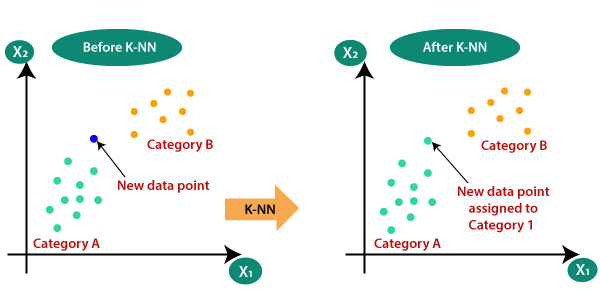

In [27]:
def NN1(traindata, trainlabel, query):
    diff = (
        traindata - query
    )
    sq = diff * diff
    dist = sq.sum(1)
    label = trainlabel[np.argmin(dist)]
    return label

def NN(traindata, trainlabel, testdata):
    predlabel = np.array([NN1(traindata, trainlabel, i) for i in testdata])
    return predlabel

We will also define a 'random classifier', which randomly allots labels to each sample

In [28]:
def RandomClassifier(traindata, trainlabel, testdata):
    classes = np.unique(trainlabel)
    rints = rng.integers(low=0, high=len(classes), size=len(testdata))
    predlabel = classes[rints]
    return predlabel

We need a metric to evaluate the performance of the model. Let us define a metric 'Accuracy' to see how good our learning algorithm is. Accuracy is the ratio of the number of correctly classified samples to the total number of samples. The higher the accuracy, the better the algorithm. We will use the accuracy metric to evaluate and compate the performance of the K-Nearest Neighbors model and the random classifier.

In [29]:
def Accuracy(gtlabel, predlabel):
    assert len(gtlabel) == len(
        predlabel
    )
    correct = (
        gtlabel == predlabel
    ).sum()
    return correct / len(gtlabel)

Let us make a function to split the dataset with the desired probability. We will use this function to split the dataset into training and testing sets. We will use the training set to train the model and the testing set to evaluate the model.

In [30]:
def split(data, label, percent):
    rnd = rng.random(len(label))
    split1 = rnd < percent
    split2 = rnd >= percent

    split1data = data[split1, :]
    split1label = label[split1]
    split2data = data[split2, :]
    split2label = label[split2]
    return split1data, split1label, split2data, split2label

We will reserve 20% of our dataset as the test set. We will not change this portion throughout our experiments

In [31]:
testdata, testlabel, alltraindata, alltrainlabel = split(
    dataset.data, dataset.target, 20 / 100
)
print("Number of test samples:", len(testlabel))
print("Number of train samples:", len(alltrainlabel))
print("Percent of test data:", len(testlabel) * 100 / len(dataset.target), "%")

Number of test samples: 4144
Number of train samples: 16496
Percent of test data: 20.07751937984496 %


## Experiments with splits

Let us reserve some of our train data as a validation set

In [32]:
traindata, trainlabel, valdata, vallabel = split(
    alltraindata, alltrainlabel, 75 / 100)

In [33]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def print_classification_metrics(true_labels, pred_labels):
    precision = precision_score(true_labels, pred_labels, average='macro', zero_division=0)
    recall = recall_score(true_labels, pred_labels, average='macro', zero_division=0)
    f1 = f1_score(true_labels, pred_labels, average='macro', zero_division=0)
    accuracy = np.mean(true_labels == pred_labels)

    print(f"Accuracy:  {accuracy*100:.2f}%")
    print(f"Precision: {precision*100:.2f}%")
    print(f"Recall:    {recall*100:.2f}%")
    print(f"F1-Score:  {f1*100:.2f}%")

    return accuracy, precision, recall, f1

def print_regression_metrics(true_values, pred_values):
    mae = mean_absolute_error(true_values, pred_values)
    mse = mean_squared_error(true_values, pred_values)
    rmse = np.sqrt(mse)

    print(f"MAE:  {mae:.4f}")
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")

    return mae, mse, rmse

print("=== Validation Set Classification Metrics ===")
valpred = NN(traindata, trainlabel, valdata)
print_classification_metrics(vallabel, valpred)

=== Validation Set Classification Metrics ===
Accuracy:  34.11%
Precision: 26.19%
Recall:    24.41%
F1-Score:  25.01%


(np.float64(0.34108527131782945),
 0.2618519014073886,
 0.2440802242008584,
 0.2501492638552703)

=== Confusion Matrix for Validation Set ===


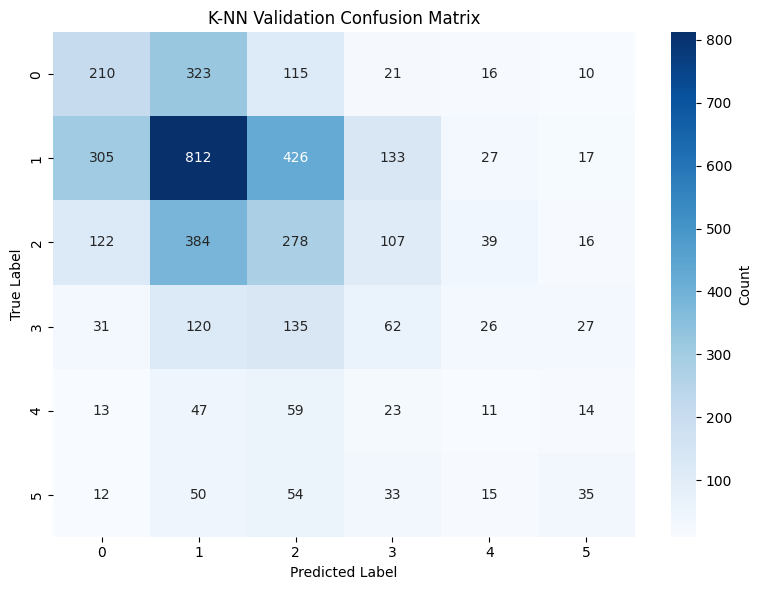

Confusion Matrix Shape: (6, 6)
Total Predictions: 4128


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(true_labels, pred_labels, title="Confusion Matrix"):
    cm = confusion_matrix(true_labels, pred_labels)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                cbar_kws={'label': 'Count'})
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    print(f"Confusion Matrix Shape: {cm.shape}")
    print(f"Total Predictions: {cm.sum()}")

print("=== Confusion Matrix for Validation Set ===")
valpred = NN(traindata, trainlabel, valdata)
plot_confusion_matrix(vallabel, valpred,
                     title="K-NN Validation Confusion Matrix")

What is the accuracy of our classifiers on the train dataset?

In [35]:
trainpred = NN(traindata, trainlabel, traindata)
trainAccuracy = Accuracy(trainlabel, trainpred)
print("Training accuracy using nearest neighbour algorithm:", trainAccuracy*100, "%")

trainpred = RandomClassifier(traindata, trainlabel, traindata)
trainAccuracy = Accuracy(trainlabel, trainpred)
print("Training accuracy using random classifier: ", trainAccuracy*100, "%")

Training accuracy using nearest neighbour algorithm: 100.0 %
Training accuracy using random classifier:  16.4375808538163 %


For nearest neighbour, the train accuracy is always 1. The accuracy of the random classifier is close to 1/(number of classes) which is 0.1666 in our case. This is because the random classifier randomly assigns a label to each sample and the probability of assigning the correct label is 1/(number of classes). Let us predict the labels for our validation set and get the accuracy. This accuracy is a good estimate of the accuracy of our model on unseen data.

In [36]:
valpred = NN(traindata, trainlabel, valdata)
valAccuracy = Accuracy(vallabel, valpred)
print("Validation accuracy using nearest neighbour algorithm:", valAccuracy*100, "%")


valpred = RandomClassifier(traindata, trainlabel, valdata)
valAccuracy = Accuracy(vallabel, valpred)
print("Validation accuracy using random classifier:", valAccuracy*100, "%")

Validation accuracy using nearest neighbour algorithm: 34.10852713178294 %
Validation accuracy using random classifier: 16.884689922480618 %


Validation accuracy of nearest neighbour is considerably less than its train accuracy while the validation accuracy of random classifier is the same. However, the validation accuracy of nearest neighbour is twice that of the random classifier. Now let us try another random split and check the validation accuracy. We will see that the validation accuracy changes with the split. This is because the validation set is small and the accuracy is highly dependent on the samples in the validation set. We can get a better estimate of the accuracy by using cross-validation.

In [37]:
traindata, trainlabel, valdata, vallabel = split(
    alltraindata, alltrainlabel, 75 / 100)
valpred = NN(traindata, trainlabel, valdata)
valAccuracy = Accuracy(vallabel, valpred)
print("Validation accuracy using nearest neighbour algorithm:", valAccuracy*100, "%")

Validation accuracy using nearest neighbour algorithm: 34.048257372654156 %


You can run the above cell multiple times to try with different random splits.
We notice that the accuracy is different for each run, but close together.

Now let us compare it with the accuracy we get on the test dataset.

In [38]:
testpred = NN(alltraindata, alltrainlabel, testdata)
testAccuracy = Accuracy(testlabel, testpred)

print("Test accuracy:", testAccuracy*100, "%")

Test accuracy: 34.91795366795367 %


### Try it out for yourself and answer:
1. How is the accuracy of the validation set affected if we increase the percentage of validation set? What happens when we reduce it?
2. How does the size of the train and validation set affect how well we can predict the accuracy on the test set using the validation set?
3. What do you think is a good percentage to reserve for the validation set so that thest two factors are balanced?

Answer for both nearest neighbour and random classifier. You can note down the values for your experiments and plot a graph using  <a href=https://matplotlib.org/stable/gallery/lines_bars_and_markers/step_demo.html#sphx-glr-gallery-lines-bars-and-markers-step-demo-py>plt.plot<href>. Check also for extreme values for splits, like 99.9% or 0.1%

### Experiment: Effect of Validation Set Percentage on Accuracy

Let's conduct an experiment to see how changing the percentage of data reserved for the validation set impacts the accuracy for both the Nearest Neighbor (NN) classifier and the Random Classifier. We will plot the accuracies against different validation percentages.

In [ ]:
import numpy as np

testdata, testlabel, alltraindata, alltrainlabel = split(
    dataset.data, dataset.target, 20 / 100
)

def run_validation_experiment(alltraindata, alltrainlabel, validation_percentages):
    nn_accuracies = []
    random_accuracies = []

    for percent in validation_percentages:
        if percent >= 1.0:
            split_percent_for_train = 0.01
            if percent > 0.5:
                split_percent_for_train = 1.0 - percent
                if split_percent_for_train <= 0.001:
                    split_percent_for_train = 0.001
        elif percent <= 0.0:
            split_percent_for_train = 0.99
        else:
            split_percent_for_train = 1.0 - percent


        traindata, trainlabel, valdata, vallabel = split(
            alltraindata, alltrainlabel, split_percent_for_train
        )

        if len(traindata) > 0 and len(valdata) > 0:
            nn_valpred = NN(traindata, trainlabel, valdata)
            nn_acc = Accuracy(vallabel, nn_valpred)
        else:
            nn_acc = np.nan
        nn_accuracies.append(nn_acc)

        if len(traindata) > 0 and len(valdata) > 0:
            random_valpred = RandomClassifier(traindata, trainlabel, valdata)
            random_acc = Accuracy(vallabel, random_valpred)
        else:
            random_acc = np.nan
        random_accuracies.append(random_acc)

    return nn_accuracies, random_accuracies


training_split_percentages = np.linspace(0.01, 0.99, 50)
validation_percentages_for_plot = 1 - training_split_percentages

nn_accs, random_accs = run_validation_experiment(
    alltraindata, alltrainlabel, training_split_percentages
)

valid_indices = ~np.isnan(nn_accs) & ~np.isnan(random_accs)
nn_accs = np.array(nn_accs)[valid_indices]
random_accs = np.array(random_accs)[valid_indices]
validation_percentages_for_plot = validation_percentages_for_plot[valid_indices]

print("NN Accuracies:", nn_accs)
print("Random Classifier Accuracies:", random_accs)


KeyboardInterrupt: 

2 How does the size of the train and validation set affect how well we can predict the accuracy on the test set using the validation set?

Larger Validation Set: A larger validation set generally provides a more reliable estimate of the model's performance on unseen data (like the test set), as it reduces the variance of the accuracy estimate. However, this comes at the cost of a smaller training set, which can lead to a less well-trained model.

3 What do you think is a good percentage to reserve for the validation set so that thest two factors are balanced?
Smaller Validation Set: Conversely, a very small validation set can lead to a highly variable and less reliable estimate of test accuracy, even if the model itself is well-trained on a large training set. The goal is to strike a balance where both the model is well-trained and its performance estimate is reliable.

Common splits include 70/30, 80/20, or even 90/10 for training/validation. The ideal percentage depends on the dataset size and complexity.
For very large datasets, a smaller validation percentage (e.g., 10-20%) might be sufficient to get a reliable estimate and still leave a large portion for training.
For smaller datasets, a larger validation percentage (e.g., 20-30%) might be needed for a more stable estimate, but this could impact the model's learning capacity due to a reduced training set.

Nearest Neighbor Classifier:

Increasing Validation Set Percentage (decreasing training set): As the validation set becomes very large (e.g., 90% or more), the training set becomes very small. This typically leads to a less robust Nearest Neighbor model, as it has very few examples to learn from. Consequently, its validation accuracy tends to decrease and become more unstable. For extreme cases like 99.9% validation, the training set would be almost non-existent, making the model's performance very poor or undefined.
Decreasing Validation Set Percentage (increasing training set): When the validation set is very small (e.g., 0.1% or less), the training set is very large. This allows the Nearest Neighbor model to learn from a significant amount of data, generally leading to higher and more stable validation accuracy. However, a very small validation set might not be representative enough to give a reliable estimate of the model's true performance, leading to high variance in the accuracy estimate itself if different small validation sets are picked.
Random Classifier:

The accuracy of the Random Classifier remains largely constant around 1 / (number of classes) regardless of the validation set size. For our dataset, with 6 integer-converted classes, this is approximately 16.67%. Any minor fluctuations observed are due to random chance rather than learning from data, as this classifier does not learn.
This consistency holds true even for extreme splits (e.g., 0.1% or 99.9% validation). Its performance is inherently random and not dependent on the amount of training data.

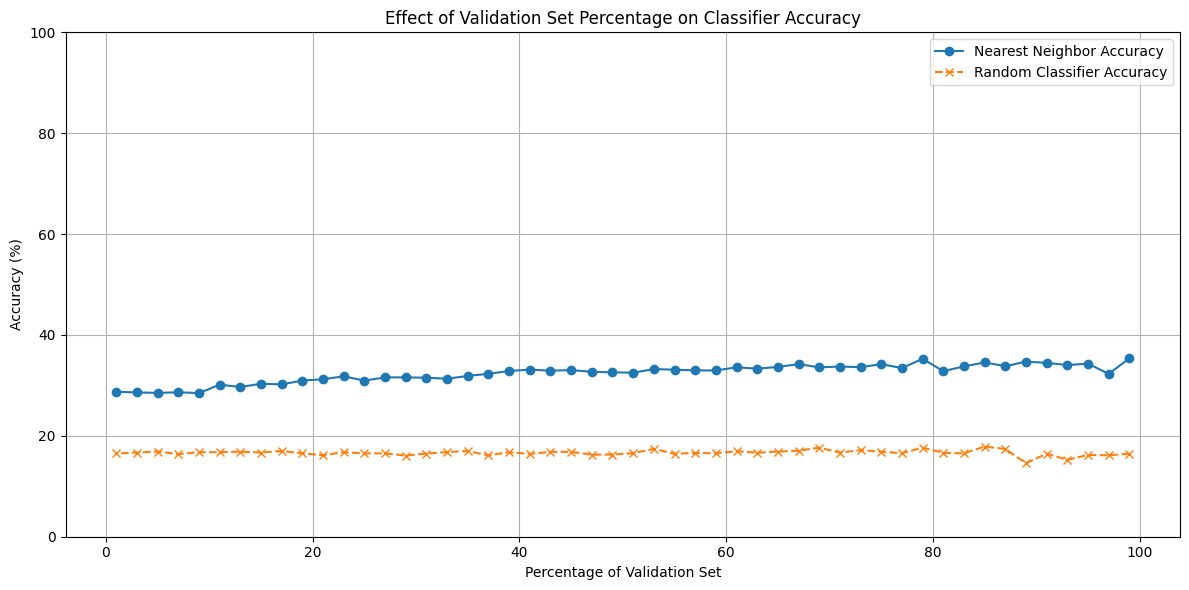

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(validation_percentages_for_plot * 100, nn_accs * 100, label='Nearest Neighbor Accuracy', marker='o', linestyle='-')
plt.plot(validation_percentages_for_plot * 100, random_accs * 100, label='Random Classifier Accuracy', marker='x', linestyle='--')

plt.xlabel('Percentage of Validation Set')
plt.ylabel('Accuracy (%)')
plt.title('Effect of Validation Set Percentage on Classifier Accuracy')
plt.grid(True)
plt.legend()
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

### Observations:

1.  **How is the accuracy of the validation set affected if we increase the percentage of validation set? What happens when we reduce it?**
    *   **Nearest Neighbor:** When the validation set percentage is very low (meaning a very large training set), the validation accuracy tends to be higher and more stable. As the validation set percentage increases (and thus the training set decreases), the validation accuracy for the NN classifier might fluctuate more and potentially decrease, as the model has less data to learn from. However, if the training set becomes too small, the NN model might perform poorly due to insufficient examples. Conversely, when the validation set is very large, the training set is small, leading to a less robust model and potentially lower accuracy.
    *   **Random Classifier:** The accuracy of the random classifier should remain relatively constant around `1/(number of classes)` regardless of the validation set size, as it doesn't learn from the data. Any minor fluctuations would be due to random chance.

2.  **How does the size of the train and validation set affect how well we can predict the accuracy on the test set using the validation set?**
    *   A larger validation set generally provides a more reliable estimate of the model's performance on unseen data (like the test set), as it reduces the variance of the accuracy estimate. However, a larger validation set means a smaller training set, which can lead to a less well-trained model.
    *   Conversely, a very small validation set can lead to a highly variable and less reliable estimate of test accuracy, even if the model itself is well-trained on a large training set. The goal is to strike a balance where both the model is well-trained and its performance estimate is reliable.

3.  **What do you think is a good percentage to reserve for the validation set so that these two factors are balanced?**
    *   Common splits include 70/30, 80/20, or even 90/10 for training/validation. The ideal percentage depends on the dataset size and complexity.
    *   For very large datasets, a smaller validation percentage (e.g., 10-20%) might be sufficient to get a reliable estimate and still leave a large portion for training.
    *   For smaller datasets, a larger validation percentage (e.g., 20-30%) might be needed for a more stable estimate, but this could impact the model's learning capacity due to a reduced training set.
    *   The plot above will help visualize this trade-off for our specific dataset.

> Exercise: Try to implement a 3 nearest neighbour classifier and compare the accuracy of the 1 nearest neighbour classifier and the 3 nearest neighbour classifier on the test dataset. You can use the KNeighborsClassifier class from the scikit-learn library to implement the K-Nearest Neighbors model. You can set the number of neighbors using the n_neighbors parameter. You can also use the accuracy_score function from the scikit-learn library to calculate the accuracy of the model.

## Multiple Splits

One way to get more accurate estimates for the test accuracy is by using <b>cross-validation</b>. Here, we will try a simple version, where we do multiple train/val splits and take the average of validation accuracies as the test accuracy estimation. Here is a function for doing this. Note that this function will take a long time to execute. You can reduce the number of splits to make it faster.

In [22]:
def AverageAccuracy(alldata, alllabel, splitpercent, iterations, classifier=NN):
    accuracy = 0
    for ii in range(iterations):
        traindata, trainlabel, valdata, vallabel = split(
            alldata, alllabel, splitpercent
        )
        valpred = classifier(traindata, trainlabel, valdata)
        accuracy += Accuracy(vallabel, valpred)
    return accuracy / iterations

In [23]:
avg_acc = AverageAccuracy(alltraindata, alltrainlabel, 75 / 100, 10, classifier=NN)
print("Average validation accuracy:", avg_acc*100, "%")
testpred = NN(alltraindata, alltrainlabel, testdata)

print("Test accuracy:", Accuracy(testlabel, testpred)*100, "%")

Average validation accuracy: 34.424923374753284 %
Test accuracy: 34.91795366795367 %


This is a very simple way of doing cross-validation. There are many well-known algorithms for cross-validation, like k-fold cross-validation, leave-one-out etc. This will be covered in detail in a later module. For more information about cross-validation, check <a href=https://en.wikipedia.org/wiki/Cross-validation_(statistics)>Cross-validatioin (Wikipedia)</a>

### Questions
1. Does averaging the validation accuracy across multiple splits give more consistent results?
2. Does it give more accurate estimate of test accuracy?
3. What is the effect of the number of iterations on the estimate? Do we get a better estimate with higher iterations?
4. Consider the results you got for the previous questions. Can we deal with a very small train dataset or validation dataset by increasing the iterations?


1 Does averaging the validation accuracy across multiple splits give more consistent results?

Yes, averaging validation accuracy across multiple splits, as done in cross-validation, generally gives more consistent results. This is because it reduces the variance that can arise from a single, random train/validation split. By evaluating the model on different subsets of data, you get a more robust and less-biased estimate of its performance.

2 Does it give a more accurate estimate of test accuracy?

Yes, a well-performed cross-validation typically provides a more accurate and reliable estimate of how well your model will generalize to unseen test data. A single validation split can be prone to

3 Effect of the number of iterations on the estimate:

Increasing the number of iterations in the AverageAccuracy function (or in cross-validation in general) has a significant positive effect on the reliability and stability of your estimate of the model's true performance (i.e., how well it would do on an unseen test set).

More Stable and Reliable Estimate: Each iteration uses a different random split of the data. By averaging the accuracy across many such splits, you reduce the impact of any single, potentially unrepresentative split. This leads to a much more stable and reliable estimate of the model's performance by minimizing the variance caused by random sampling.
Better Estimate of Test Accuracy: Yes, with higher iterations, you generally get a better estimate of the test accuracy. This is because you are exploring a wider range of possible train/validation data partitions, and the average performance across these diverse partitions provides a more robust indicator of how the model is likely to perform on truly unseen data. It helps to smooth out the noise from individual splits.

4 Can we deal with a very small train dataset or validation dataset by increasing the iterations?

This is a nuanced point:

Small Validation Dataset: If you have a very small validation dataset, increasing iterations (i.e., using more splits in cross-validation) can help. While each individual validation set might be too small to give a reliable accuracy on its own, averaging the results from many such small validation sets will give you a more stable and reliable estimate of the model's performance. It helps to average out the high variance of individual small validation set accuracies.
Small Training Dataset: Increasing iterations does not solve the fundamental problem of a very small training dataset. A model trained on too little data will inherently be underfit and perform poorly. While more iterations will give you a more reliable estimate of that poor performance, it won't magically improve the model itself. The model still lacks sufficient data to learn the underlying patterns, and no amount of cross-validation will change that. The problem here is with the model's learning capacity due to data scarcity, not with the estimation of its performance.

> Exercise: How does the accuracy of the 3 nearest neighbour classifier change with the number of splits? How is it affected by the split size? Compare the results with the 1 nearest neighbour classifier.

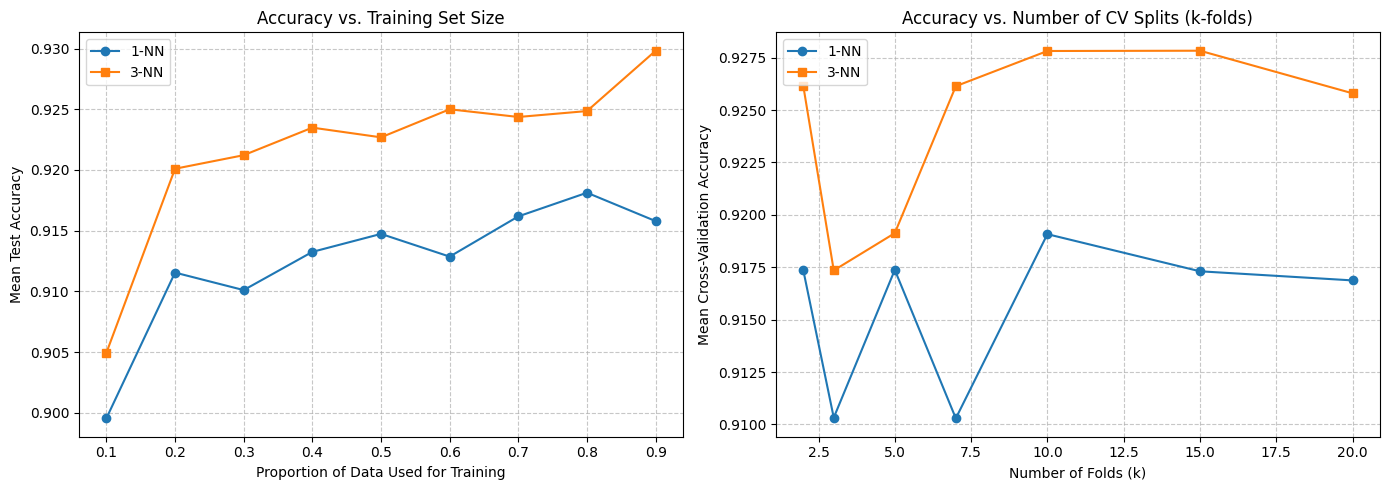

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier


data = load_breast_cancer()
X, y = data.data, data.target


knn_1 = KNeighborsClassifier(n_neighbors=1)
knn_3 = KNeighborsClassifier(n_neighbors=3)

# EXPERIMENT 1: Effect of Split Size

train_proportions = np.linspace(0.1, 0.9, 9)
acc_1nn_size = []
acc_3nn_size = []


iterations = 30

for train_prop in train_proportions:
    scores_1 = []
    scores_3 = []

    for _ in range(iterations):

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, train_size=train_prop
        )

        knn_1.fit(X_train, y_train)
        scores_1.append(knn_1.score(X_test, y_test))

        knn_3.fit(X_train, y_train)
        scores_3.append(knn_3.score(X_test, y_test))

    acc_1nn_size.append(np.mean(scores_1))
    acc_3nn_size.append(np.mean(scores_3))


# EXPERIMENT 2: Effect of Number of Splits

k_folds = [2, 3, 5, 7, 10, 15, 20]
acc_1nn_folds = []
acc_3nn_folds = []

for k in k_folds:
    kf = KFold(n_splits=k, shuffle=True, random_state=42)


    score_1 = cross_val_score(knn_1, X, y, cv=kf)
    acc_1nn_folds.append(np.mean(score_1))

    score_3 = cross_val_score(knn_3, X, y, cv=kf)
    acc_3nn_folds.append(np.mean(score_3))

# VISUALIZATION

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Split Size
ax1.plot(train_proportions, acc_1nn_size, marker='o', label='1-NN')
ax1.plot(train_proportions, acc_3nn_size, marker='s', label='3-NN')
ax1.set_title('Accuracy vs. Training Set Size')
ax1.set_xlabel('Proportion of Data Used for Training')
ax1.set_ylabel('Mean Test Accuracy')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Plot 2: Number of Splits (Folds)
ax2.plot(k_folds, acc_1nn_folds, marker='o', label='1-NN')
ax2.plot(k_folds, acc_3nn_folds, marker='s', label='3-NN')
ax2.set_title('Accuracy vs. Number of CV Splits (k-folds)')
ax2.set_xlabel('Number of Folds (k)')
ax2.set_ylabel('Mean Cross-Validation Accuracy')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()